# 26 — Portfolio Construction

Week 6, Day 2. Takes the z-score signal panel (3Y and 7Y only), sizes each position so its DV01 = $10,000, computes factor-neutral hedge legs, and saves the full position history to parquet.

This notebook walks through:
1. Single-date walkthrough — what the function does step by step
2. DV01 sizing — why face values differ across maturities
3. Full history summary — positions over time, signal counts, notional breakdown

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from termstructure.backtest.portfolio import (
    SIGNAL_MATURITIES,
    construct_portfolio,
    _position_legs,
)
from termstructure.risk.hedge import (
    compute_bond_krd, bond_factor_exposure, pca_loadings_at_buckets,
)
from termstructure.bonds.pricing import dv01 as _dv01
from termstructure.curves.svensson import svensson_zero_rate

# Load standing data
signal = pd.read_parquet('../data/processed/signal_panel.parquet')
signal['date'] = pd.to_datetime(signal['date'])

params = pd.read_parquet('../data/processed/svensson_params.parquet')
params['date'] = pd.to_datetime(params['date'])
params = params.set_index('date')

positions = pd.read_parquet('../data/processed/portfolio_positions.parquet')
positions['date'] = pd.to_datetime(positions['date'])

print(f'Signal panel  : {signal["date"].min().date()} to {signal["date"].max().date()}')
print(f'Portfolio rows: {len(positions):,}  ({positions["date"].nunique():,} dates)')
print(f'Signal legs   : {(positions["leg_type"]=="signal").sum():,}')

Signal panel  : 1971-09-27 to 2024-12-31
Portfolio rows: 9,856  (1,662 dates)
Signal legs   : 2,464


## 1. Single-date walkthrough

Pick a date that has signals at both 3Y and 7Y simultaneously and step through what the construction function does.

In [2]:
# Find a date with signals at both maturities
active = signal[
    signal['maturity'].isin(SIGNAL_MATURITIES) & (signal['direction'] != 0)
]
both = (
    active.groupby('date')['maturity']
    .nunique()
    .pipe(lambda s: s[s == 2])
)
# Pick the first such date after 2000
demo_date = both[both.index >= '2000-01-01'].index[0]
sv = params.loc[demo_date, ['beta0','beta1','beta2','beta3','lambda1','lambda2']].to_numpy(float)

today_sig = signal[signal['date'] == demo_date]
demo_active = today_sig[today_sig['maturity'].isin(SIGNAL_MATURITIES) & (today_sig['direction'] != 0)]

print(f'Demo date: {demo_date.date()}')
print()
print('Active signals:')
print(demo_active[['maturity','z_score','direction']].to_string(index=False))

Demo date: 2000-01-04

Active signals:
 maturity   z_score  direction
        3 -3.121664         -1
        7  2.291216          1


In [3]:
df = construct_portfolio(demo_date, sv, today_sig)

print(f'Portfolio legs for {demo_date.date()}:')
print()
display_cols = ['signal_maturity','leg_maturity','leg_type','direction','z_score','notional','dv01']
styled = df[display_cols].copy()
styled['notional'] = styled['notional'].map('${:>16,.0f}'.format)
styled['dv01']     = styled['dv01'].map('${:>10,.0f}'.format)
styled['z_score']  = styled['z_score'].map(lambda x: f'{x:+.3f}' if not pd.isna(x) else '—')
print(styled.to_string(index=False))

Portfolio legs for 2000-01-04:

 signal_maturity  leg_maturity leg_type  direction z_score          notional        dv01
               7           7.0   signal          1  +2.291 $      18,026,675 $    10,000
               7           2.0    hedge          1       — $         290,882 $        54
               7           5.0    hedge          1       — $     -14,037,729 $     5,927
               7          10.0    hedge          1       — $      -5,715,679 $     4,128
               3           3.0   signal         -1  -3.122 $     -37,072,534 $    10,000
               3           2.0    hedge         -1       — $      35,620,373 $     6,603
               3           5.0    hedge         -1       — $       8,047,854 $     3,398
               3          10.0    hedge         -1       — $               0 $         0


## 2. DV01 sizing

Modified duration increases with maturity, so equal-DV01 sizing means shorter bonds require larger face values. The table below shows how face value varies across maturities for a $10,000 DV01 target.

In [4]:
target_dv01 = 10_000
# Use the demo date's curve
rows = []
for mat in [2, 3, 5, 7, 10]:
    ytm = svensson_zero_rate(float(mat), *sv)
    dv01_per_dollar = _dv01(ytm, float(mat), ytm, face=1.0)
    face = target_dv01 / dv01_per_dollar
    rows.append({
        'maturity': mat,
        'ytm_pct': ytm * 100,
        'mod_duration': dv01_per_dollar / 1e-4,
        'dv01_per_1M': dv01_per_dollar * 1e6,
        'face_for_10k_dv01': face,
    })

sizing = pd.DataFrame(rows).set_index('maturity')
print(f'Sizing table  (curve date: {demo_date.date()}, DV01 target = ${target_dv01:,})')
print()
print(sizing.rename(columns={
    'ytm_pct':           'YTM (%)',
    'mod_duration':      'Mod Duration (yr)',
    'dv01_per_1M':       'DV01 / $1M face ($)',
    'face_for_10k_dv01': 'Face for $10K DV01 ($)',
}).round(2).to_string())

Sizing table  (curve date: 2000-01-04, DV01 target = $10,000)

          YTM (%)  Mod Duration (yr)  DV01 / $1M face ($)  Face for $10K DV01 ($)
maturity                                                                         
2            6.22               1.85               185.36             53948773.85
3            6.25               2.70               269.74             37072533.51
5            6.40               4.22               422.21             23684853.09
7            6.53               5.55               554.73             18026674.62
10           6.65               7.22               722.15             13847554.90


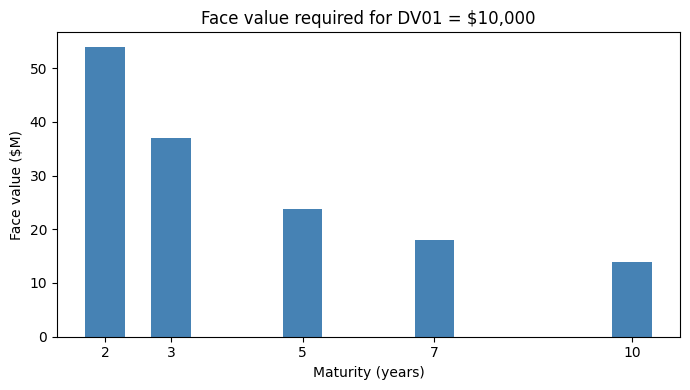

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sizing.index, sizing['face_for_10k_dv01'] / 1e6, color='steelblue', width=0.6)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Face value ($M)')
ax.set_title('Face value required for DV01 = $10,000')
ax.set_xticks(sizing.index)
plt.tight_layout()
plt.show()

## 3. Factor neutrality check

For each position on the demo date, verify that the signed notionals × factor exposures sum to zero across all legs.

In [6]:
L = pca_loadings_at_buckets()

for sig_mat in sorted(df['signal_maturity'].unique()):
    pos = df[df['signal_maturity'] == sig_mat]
    direction = int(pos[pos['leg_type']=='signal']['direction'].iloc[0])
    z = pos[pos['leg_type']=='signal']['z_score'].iloc[0]
    print(f'{sig_mat}Y signal  direction={direction:+d}  z={z:+.3f}')
    total = np.zeros(3)
    for _, row in pos.iterrows():
        krd = compute_bond_krd(float(row['leg_maturity']), sv)
        exp = bond_factor_exposure(krd, L)
        contrib = row['notional'] * exp
        total += contrib
        ltype = row['leg_type']
        print(f'  {row["leg_maturity"]:4.0f}Y {ltype:6s}  notional={row["notional"]:>16,.0f}  exp={np.round(exp,4)}')
    print(f'  TOTAL  {np.round(total, 4)}  (should be ~0)')
    print()

3Y signal  direction=-1  z=-3.122
     3Y signal  notional=     -37,072,534  exp=[ 0.9608 -0.858   0.2808]
     2Y hedge   notional=      35,620,373  exp=[ 0.6199 -0.7496  0.3951]
     5Y hedge   notional=       8,047,854  exp=[ 1.6818 -0.6347 -0.4551]
    10Y hedge   notional=               0  exp=[ 2.8044  0.8373 -2.5472]
  TOTAL  [ 0. -0.  0.]  (should be ~0)

7Y signal  direction=+1  z=+2.291
     7Y signal  notional=      18,026,675  exp=[ 2.1888 -0.2167 -1.1684]
     2Y hedge   notional=         290,882  exp=[ 0.6199 -0.7496  0.3951]
     5Y hedge   notional=     -14,037,729  exp=[ 1.6818 -0.6347 -0.4551]
    10Y hedge   notional=      -5,715,679  exp=[ 2.8044  0.8373 -2.5472]
  TOTAL  [0. 0. 0.]  (should be ~0)



## 4. Full history summary

In [7]:
sig_legs = positions[positions['leg_type'] == 'signal'].copy()

print('Signal leg counts by maturity and direction:')
print(sig_legs.groupby(['signal_maturity','direction']).size().unstack(fill_value=0).to_string())
print()
print('Signal DV01 sanity (should all be $10,000):')
print(sig_legs['dv01'].describe().round(6).to_string())

Signal leg counts by maturity and direction:
direction         -1    1
signal_maturity          
3                646  593
7                578  647

Signal DV01 sanity (should all be $10,000):
count     2464.0
mean     10000.0
std          0.0
min      10000.0
25%      10000.0
50%      10000.0
75%      10000.0
max      10000.0


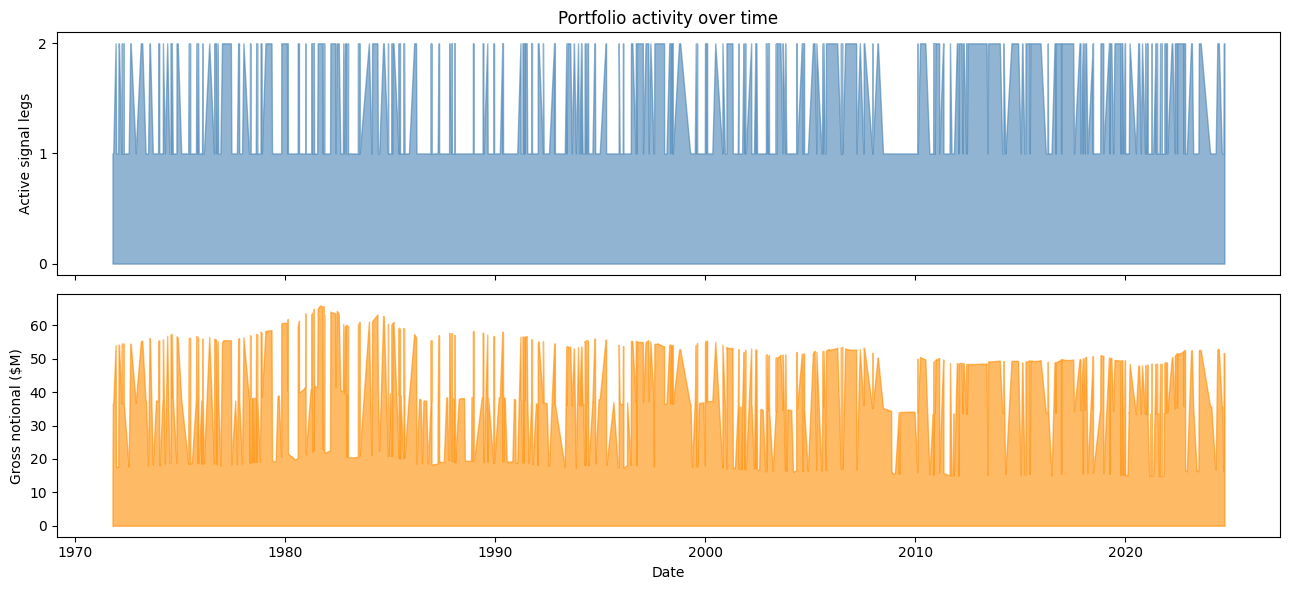

In [8]:
# Active positions per day (signal legs only)
daily_count = sig_legs.groupby('date').size()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# Top: number of active signal legs per day
ax = axes[0]
ax.fill_between(daily_count.index, daily_count.values, alpha=0.6, color='steelblue')
ax.set_ylabel('Active signal legs')
ax.set_title('Portfolio activity over time')
ax.set_yticks([0, 1, 2])

# Bottom: gross notional of signal legs (absolute value)
ax = axes[1]
daily_notional = sig_legs.groupby('date')['notional'].apply(lambda x: x.abs().sum()) / 1e6
ax.fill_between(daily_notional.index, daily_notional.values, alpha=0.6, color='darkorange')
ax.set_ylabel('Gross notional ($M)')
ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

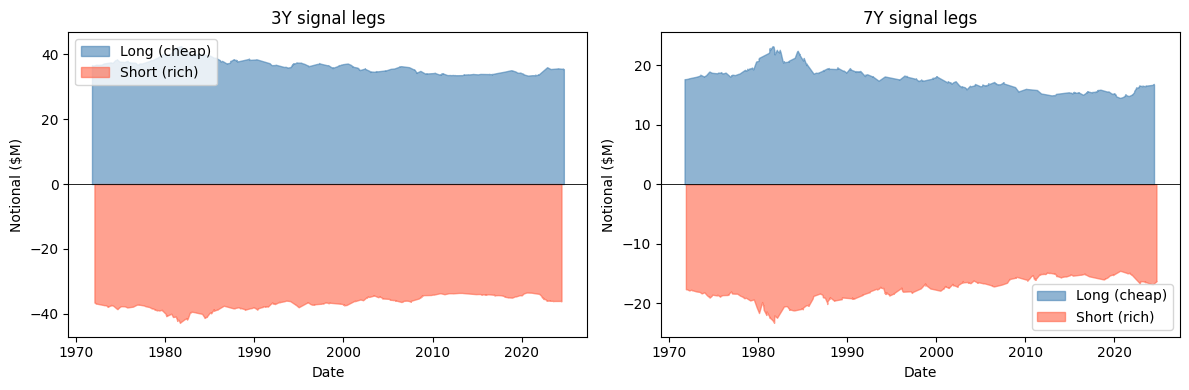

In [9]:
# Breakdown: long vs short, 3Y vs 7Y
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mat in zip(axes, [3, 7]):
    sub = sig_legs[sig_legs['signal_maturity'] == mat].copy()
    longs  = sub[sub['direction'] ==  1].set_index('date')['notional'] / 1e6
    shorts = sub[sub['direction'] == -1].set_index('date')['notional'] / 1e6
    ax.fill_between(longs.index,  longs.values,  alpha=0.6, color='steelblue', label='Long (cheap)')
    ax.fill_between(shorts.index, shorts.values, alpha=0.6, color='tomato',    label='Short (rich)')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'{mat}Y signal legs')
    ax.set_xlabel('Date')
    ax.set_ylabel('Notional ($M)')
    ax.legend()

plt.tight_layout()
plt.show()